# Lab 5: Introducing GeoAI
In the words of the developers themselves:
"GeoAI is a comprehensive Python package designed to bridge artificial intelligence (AI) and geospatial data analysis, providing researchers and practitioners with intuitive tools for applying machine learning techniques to geographic data. The package offers a unified framework for processing satellite imagery, aerial photographs, and vector data using state-of-the-art deep learning models. GeoAI integrates popular AI frameworks including PyTorch, Transformers, PyTorch Segmentation Models, and specialized geospatial libraries like torchange, enabling users to perform complex geospatial analyses with minimal code."
- [GeoAI 2025](https://opengeoai.org/)


The aim of the this lab is take the knowldege of fundamental mechanics in both satellite data and AI that you have this far gained- and apply them via the bridge that GeoAI provides.

This lab is a modified version of the following tutorial:
- [GeoAI Workshop 2025](https://www.youtube.com/watch?v=jdK-cleFUkc&ab_channel=OpenGeospatialSolutions)

A key thing to be aware of- we are stepping away here from using the GEE API, and taking a pure Python approach. So we have to go get our own data, and all our processing is happening on our 'local'.


# Task 1: mapping surface water with S2
We start by installing the required package and setting CoLab to run on a GPU. Until now, we have been running all our code on a CPU, a GPU allows us to use neural networks much more effectively.



To use GPU, please click the "Runtime" menu and select "Change runtime type". Then select "T4 GPU" from the dropdown menu. GPU acceleration is highly recommended for training deep learning models, as it can reduce training time from hours to minutes. It may already be set to this, but check!

If you are running this lab on your own laptop, follow the installation instructions linked below in order to ensure that GPU and subsequent CUDA usage is connected up correctly [people using Colab, no need to do so]:
- https://opengeoai.org/installation/
- https://aibook.gishub.org/book/foundations/setup/


First we will test to make sure our GPU is working in Colab. The cell below should produce something like:

```
PyTorch: 2.x.x
CUDA available: True
GPU: Tesla T4
```

If it does not, check that your runtime is set to a T4 GPU. If it is set to that and is still not using the CUDA and T4, restart the runtime.

In [3]:
# Check Colab GPU
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    raise RuntimeError(
        "No CUDA GPU detected. Select Runtime > Change runtime type > T4 GPU."
    )

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


Next we install Geo-AI:

In [4]:
# Install GeoAI
%pip install geoai --user

Note: you may need to restart the kernel to use updated packages.


And now we import and test that they are going to play nice together. The following should be the reported status:



```
GeoAI: 0.4x.x
PyTorch: 2.xx.x+cu128
CUDA available: True
CUDA version: 12.x
GPU: Tesla T4
GeoAI device: cuda
```



In [5]:
# Import key libs and check function of them
import torch
import geoai

print("GeoAI:", geoai.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No CUDA GPU detected.")

GeoAI: 0.43.1
PyTorch: 2.11.0+cu130
CUDA available: True
CUDA version: 13.0
GPU:     NVIDIA GeForce RTX 4070 Ti SUPER


### Basemap configuration (run this before any map)

The interactive maps in this lab are built by `leafmap` on top of `ipyleaflet`.
Its default basemap is OpenStreetMap, and OSM's tile usage policy returns
**HTTP 403** to the Colab client, so the maps come back blank, grey or with a 403 tile error.

Passing a local GeoTIFF as `basemap=` does *not* fix this: your raster is added
as an extra layer, but the default OSM layer is still there underneath.

The cell below is a custom interactive display batch of code. Just run the code whenever you start a new session to have it available.

In [6]:
# @title
# =====================================================================
# Local-data-only interactive map — no basemap, no tile server, no
# network calls except a one-time load of the Leaflet.js library itself
# from a CDN (that is a small JS/CSS file your browser fetches once,
# not a per-pan-and-zoom map-tile request, so it isn't subject to the
# same rate limits/blocks as OSM or Esri tiles).
#
# The map runs in Leaflet's CRS.Simple mode: there is no basemap layer
# of any kind, only the imagery/masks/vectors you hand it, drawn on a
# flat plane using the raster's own coordinate system (metres, for a
# projected CRS). Panning and zooming are native Leaflet — fully
# interactive, nothing pre-rendered.
#
# Usage:
#   show_interactive(raster=train_raster_path, vector=train_vector_path,
#                     title="Training scene")
#
#   show_interactive(raster=test_raster_path, mask=masks_path,
#                     probability=probability_path, title="Test predictions")
#
#   show_interactive(raster=test_raster_path, vector=gdf_filtered,
#                     vector_column="area_m2", title="Filtered detections")
# =====================================================================

import base64, io, json, uuid
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
import rasterio
from rasterio.enums import Resampling
from IPython.display import HTML, display

try:
    import geopandas as gpd
except ImportError:
    gpd = None

_MAX_PX = 1600  # longest side of any image actually embedded in the page


def _read_scene(path, indexes, max_px=_MAX_PX):
    with rasterio.open(path) as src:
        h, w = src.height, src.width
        scale = min(1.0, max_px / max(h, w))
        out_h, out_w = max(1, round(h * scale)), max(1, round(w * scale))
        data = src.read(
            indexes=indexes, out_shape=(len(indexes), out_h, out_w),
            resampling=Resampling.bilinear, masked=True,
        )
        return data, src.bounds, src.crs


def _stretch(band, divider=None, pct=(2, 98)):
    band = band.astype("float32")
    if divider:
        s = band / float(divider)
    else:
        valid = np.ma.compressed(band)
        valid = valid[np.isfinite(valid)]
        if valid.size:
            lo, hi = np.percentile(valid, pct[0]), np.percentile(valid, pct[1])
        else:
            lo, hi = 0.0, 1.0
        if hi <= lo:
            hi = lo + 1e-6
        s = (band - lo) / (hi - lo)
    return np.clip(np.ma.filled(s, 0.0), 0.0, 1.0)


def _png_uri(rgba):
    buf = io.BytesIO()
    plt.imsave(buf, np.clip(rgba, 0.0, 1.0), format="png")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")


def _raster_overlay(path, indexes=None, divider=None, pct=(2, 98), cmap="gray"):
    with rasterio.open(path) as src:
        n = src.count
    if indexes is None:
        indexes = [1, 2, 3] if n >= 3 else [1]
    data, bounds, crs = _read_scene(path, indexes)
    if len(indexes) >= 3:
        rgb = np.dstack([_stretch(data[i], divider, pct) for i in range(3)])
        mask = np.ma.getmaskarray(data)
        alpha = np.ones(rgb.shape[:2], "float32")
        if mask is not np.ma.nomask and mask.any():
            alpha = (~np.any(mask, axis=0)).astype("float32")
        rgba = np.dstack([rgb, alpha])
    else:
        band = _stretch(data[0], divider, pct)
        rgba = plt.get_cmap(cmap)(band)
        m = np.ma.getmaskarray(data[0])
        if m is not np.ma.nomask:
            rgba[..., 3] = np.where(m, 0.0, 1.0)
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _mask_overlay(path, nodata=0, color="red", alpha=0.55):
    data, bounds, crs = _read_scene(path, [1])
    band = data[0]
    hit = np.ma.filled(band, nodata) != nodata
    m = np.ma.getmaskarray(band)
    if m is not np.ma.nomask:
        hit &= ~m
    r, g, b = to_rgb(color)
    rgba = np.zeros(hit.shape + (4,), "float32")
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = r, g, b
    rgba[..., 3] = hit.astype("float32") * alpha
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _probability_overlay(path, band=2, cmap="magma", alpha=0.75, min_display=0.0):
    data, bounds, crs = _read_scene(path, [band])
    p = data[0].astype("float32")
    finite = np.ma.compressed(p)
    if finite.size and np.nanmax(finite) > 1.5:  # stored as 0-255 or 0-100
        p = p / (255.0 if np.nanmax(finite) > 100.0 else 100.0)
    filled = np.ma.filled(p, 0.0)
    rgba = plt.get_cmap(cmap)(np.clip(filled, 0.0, 1.0))
    rgba[..., 3] = np.where(filled < min_display, 0.0, alpha)
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _jsonable(v):
    if isinstance(v, (np.floating,)):
        return round(float(v), 4)
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, float):
        return round(v, 4)
    if isinstance(v, (int, str)):
        return v
    return None


def _vector_features(source, target_crs, column=None):
    if gpd is None:
        raise ImportError("geopandas is required to display a vector layer")
    gdf = source if hasattr(source, "geometry") else gpd.read_file(source)
    if target_crs is not None and gdf.crs is not None and gdf.crs != target_crs:
        gdf = gdf.to_crs(target_crs)

    values = None
    if column and column in gdf.columns:
        values = gdf[column].astype(float)
    vmin, vmax = (float(values.min()), float(values.max())) if values is not None and len(values) else (0.0, 1.0)
    cmap = plt.get_cmap("viridis")

    feats = []
    for i, (_, row) in enumerate(gdf.iterrows()):
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        if geom.geom_type == "Polygon":
            polys = [geom]
        elif geom.geom_type == "MultiPolygon":
            polys = list(geom.geoms)
        else:
            continue
        rings = [[[y, x] for x, y in poly.exterior.coords] for poly in polys]
        if not rings:
            continue
        color = "#3388ff"
        if values is not None:
            v = values.iloc[i]
            t = 0.5 if vmax <= vmin else (v - vmin) / (vmax - vmin)
            rc = cmap(t)
            color = "#%02x%02x%02x" % tuple(int(255 * c) for c in rc[:3])
        props = {}
        for k, v in row.drop(labels="geometry").items():
            jv = _jsonable(v)
            if jv is not None:
                props[k] = jv
        feats.append({"rings": rings, "color": color, "props": props})
    return feats


def show_interactive(
    raster=None, indexes=None, divider=None, pct=(2, 98), cmap="gray",
    mask=None, mask_nodata=0, mask_color="red", mask_alpha=0.55,
    probability=None, probability_band=2, probability_cmap="magma",
    probability_alpha=0.75, probability_min_display=0.0,
    vector=None, vector_column=None, vector_label=None,
    title=None, height=560,
):
    """Interactive pan/zoom map of local rasters and vectors. No basemap."""
    if raster is None and mask is None and probability is None:
        raise ValueError("Pass at least one of raster=, mask=, probability=")

    parts = []
    if raster is not None:
        parts.append(("Imagery", _raster_overlay(raster, indexes, divider, pct, cmap), True))
    if mask is not None:
        parts.append(("Prediction", _mask_overlay(mask, mask_nodata, mask_color, mask_alpha), True))
    if probability is not None:
        parts.append((
            "Probability",
            _probability_overlay(probability, probability_band, probability_cmap,
                                  probability_alpha, probability_min_display),
            False,
        ))

    ref_crs = next((r["crs"] for _, r, _ in parts if r["crs"] is not None), None)
    b0 = parts[0][1]["bounds"]
    west, south, east, north = b0.left, b0.bottom, b0.right, b0.top
    for _, r, _ in parts[1:]:
        b = r["bounds"]
        west, south = min(west, b.left), min(south, b.bottom)
        east, north = max(east, b.right), max(north, b.top)
    ox, oy = west, south

    def leaflet_bounds(b):
        return [[b.bottom - oy, b.left - ox], [b.top - oy, b.right - ox]]

    image_layers = [
        {"name": name, "url": r["uri"], "bounds": leaflet_bounds(r["bounds"]), "default_on": on}
        for name, r, on in parts
    ]

    vector_layer = None
    if vector is not None:
        feats = _vector_features(vector, ref_crs, vector_column)
        for f in feats:
            f["rings"] = [[[y - oy, x - ox] for y, x in ring] for ring in f["rings"]]
        vector_layer = {"name": vector_label or "Vector", "features": feats}

    div_id = "map_" + uuid.uuid4().hex[:10]
    payload = {
        "images": image_layers,
        "vector": vector_layer,
        "fit_bounds": [[0, 0], [north - oy, east - ox]],
        "title": title,
    }
    payload_json = json.dumps(payload).replace("</script", "<\\/script")

    html = f"""
<div id="{div_id}" style="height:{height}px;width:100%;border:1px solid #ccc;border-radius:4px;"></div>
<script>
(function() {{
  function ensureLeaflet(cb) {{
    if (window.L) {{ cb(); return; }}
    var css = document.createElement('link');
    css.rel = 'stylesheet';
    css.href = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.css';
    document.head.appendChild(css);
    var script = document.createElement('script');
    script.src = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.js';
    script.onload = cb;
    document.head.appendChild(script);
  }}

  function init() {{
    var data = {payload_json};
    var map = L.map('{div_id}', {{
      crs: L.CRS.Simple,
      minZoom: -10,
      maxZoom: 30,
      zoomSnap: 0.1,
      zoomDelta: 0.5,
      attributionControl: false,
    }});

    var overlays = {{}};
    data.images.forEach(function(img) {{
      var layer = L.imageOverlay(img.url, img.bounds, {{opacity: 1}});
      overlays[img.name] = layer;
      if (img.default_on) layer.addTo(map);
    }});

    if (data.vector) {{
      var group = L.layerGroup();
      data.vector.features.forEach(function(f) {{
        var poly = L.polygon(f.rings, {{color: f.color, weight: 1.5, fillOpacity: 0.25}});
        var keys = Object.keys(f.props);
        if (keys.length) {{
          var rows = keys.map(function(k) {{
            return '<tr><td style="padding-right:8px;color:#666;">' + k + '</td><td>' + f.props[k] + '</td></tr>';
          }}).join('');
          poly.bindPopup('<table>' + rows + '</table>');
        }}
        poly.addTo(group);
      }});
      overlays[data.vector.name] = group;
      group.addTo(map);
    }}

    if (Object.keys(overlays).length > 1) {{
      L.control.layers(null, overlays, {{collapsed: false}}).addTo(map);
    }}
    L.control.scale({{metric: true, imperial: false}}).addTo(map);
    map.fitBounds(data.fit_bounds);

    if (data.title) {{
      var titleCtl = L.control({{position: 'topleft'}});
      titleCtl.onAdd = function() {{
        var div = L.DomUtil.create('div');
        div.style.cssText = 'background:white;padding:4px 8px;font:14px sans-serif;'
          + 'border-radius:4px;box-shadow:0 1px 4px rgba(0,0,0,.3);margin-top:8px;';
        div.innerHTML = data.title;
        return div;
      }};
      titleCtl.addTo(map);
    }}
  }}

  ensureLeaflet(init);
}})();
</script>
"""
    display(HTML(html))

print('Custom display tool loaded')

Custom display tool loaded


Next, we will get the training data. In this case, GeoAI have linked to the work of Xin Luo who has prepped the [Earth Surface Water](https://zenodo.org/records/5205674#.Y4iEFezP1hE) Dataset from Zenodo, which contains Sentinel-2 imagery with 6 spectral bands and corresponding water masks. This is a high quality dataset that is a good example of 'ready to go' data.



In [7]:
# Access the data
url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/dset-s2.zip"
data_dir = geoai.download_file(url, output_path=r"E:\python_project\CV\dset-s2.zip")

As ever, we will use the training images and masks to train our model, then evaluate performance on the completely independent validation set.

In [8]:
import os
os.chdir(r"E:\python_project\CV")

In [9]:
# Here we create the file directories into which our data will be seperated and generated
images_dir = f"{data_dir}/dset-s2/tra_scene"
masks_dir = f"{data_dir}/dset-s2/tra_truth"
tiles_dir = f"{data_dir}/dset-s2/tiles"

We'll create smaller training tiles from the large GeoTIFF images. Note that we have multiple Sentinel-2 scenes in the training and validation sets, we will use the [GeoAI] export_geotiff_tiles_batch function to export tiles from each scene.

In [10]:
# This may take a bit of time to run, as it cycles through all the data
result = geoai.export_geotiff_tiles_batch(
    images_folder=images_dir,
    masks_folder=masks_dir,
    output_folder=tiles_dir,
    tile_size=512,
    stride=256,
    quiet=True,
)

**Q1**: With a tile_size of 512, what is the area in m2 covered by a single tile? With stride length of 256, what is the overlap of those tiles?

**Answer:** The Sentinel-2 imagery has a spatial resolution of 10 m per pixel. Therefore, a 512 × 512 pixel tile covers (5120 \times 5120) m, giving a total area of 26,214,400 m² (approximately 26.21 km²). With a stride of 256 pixels, successive tiles are shifted by only half the tile width, producing an overlap of 256 pixels, or 2560 m (50%), in each direction. For horizontally or vertically adjacent tiles, this corresponds to an overlapping area of 13,107,200 m².

Now we'll train a semantic segmentation model specifically for **6-channel** Sentinel-2 imagery. The key difference from our previous model is the input channel configuration.

Important parameters to note:
- num_channels=6: Accommodate the 6 Sentinel-2 spectral bands (Blue, Green, Red, NIR, SWIR1, SWIR2)
- Architecture is a U-Net + ResNet34: these are proven effective for multispectral imagery


Let's train the model using the Sentinel-2 tiles. As the model runs, click on the resourcs tab (underlined in red in the screenshot below) and monitor what elements of your resources you are using. About 1-2 minutes in you should see the GPU RAM jmup up, as per below, as the model and data is loaded in:


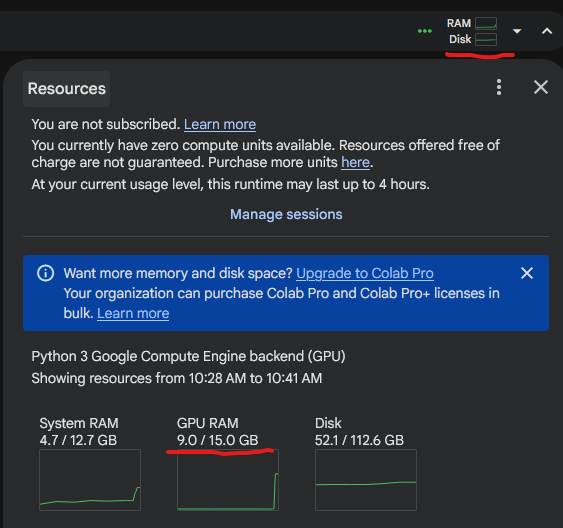

In [11]:
# This will take at least 5 minutes to run
# Take the time to search/google/use AI to understand what each of the variables going into this function do
geoai.train_segmentation_model(
    images_dir=f"{tiles_dir}/images",
    labels_dir=f"{tiles_dir}/masks",
    output_dir=f"{tiles_dir}/unet_models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=6,
    num_classes=2,
    batch_size=8,
    num_epochs=10,
    learning_rate=0.001,
    val_split=0.2,
    verbose=True,
)

print('Training complete!')

Training complete!


**Q2**: Explain why using U-Net and ResNet34 together is a good choice when working with multi-spectral imagery. Use at least two references in your response.

**Answer:** Answer: U-Net and ResNet34 complement each other well for multispectral semantic segmentation. ResNet34 acts as the encoder, progressively converting the input bands into hierarchical feature maps. Its residual connections make deeper feature extraction easier to optimise, allowing the network to learn combinations of spectral and spatial information such as differences between water, vegetation and built surfaces across several bands (He et al., 2016). U-Net then acts as the segmentation framework: its decoder upsamples these encoded features back to the original image resolution, while skip connections transfer higher-resolution information from the encoder to the decoder. This helps preserve object boundaries and spatial detail, which are important when assigning a class to every pixel (Ronneberger et al., 2015).
This combination is particularly useful for multispectral imagery because the input contains more information than ordinary RGB imagery. Multiple spectral bands can be supplied as separate input channels so that the encoder can learn both relationships between bands and spatial patterns within the image. U-Net with a ResNet34 encoder has also been used as a baseline for segmentation of multispectral Sentinel-2 imagery, demonstrating that the architecture is applicable to satellite data (Grabowski et al., 2022). An important implementation detail is that a standard ImageNet ResNet34 expects three RGB channels; therefore, when more spectral bands are used, the model's input layer must be configured or adapted to accept the required number of channels.

References
Grabowski, B., Ziaja, M., Kawulok, M., Longépé, N., Le Saux, B., & Nalepa, J. (2022). Self-configuring nnU-Nets detect clouds in satellite images. arXiv:2210.13659.

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 770–778.

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. Medical Image Computing and Computer-Assisted Intervention (MICCAI), 234–241.

AI acknowledgement: This work used ChatGPT 5.6 SoL to generate initial answer and find reference. This was done on 08/10/2026.

**Q3**: What is the learning_rate and what is the likely effect that reducing it will have on your model?

**Answer**: The learning rate controls how large a step the optimiser takes when updating the model weights during training. If the learning rate is reduced, the weight updates become smaller, so training is usually slower but more stable and may converge more smoothly. However, if it is reduced too much, the model may learn very slowly or fail to reach a good solution within the available number of epochs.

This model took me 4 to 6 minutes to run on the GPU. If it is taking you more than that, check that you are not still stuck using a CPU (it will take a LOT longer if on a CPU).

With one line of code, we can now take a look at the model performance:

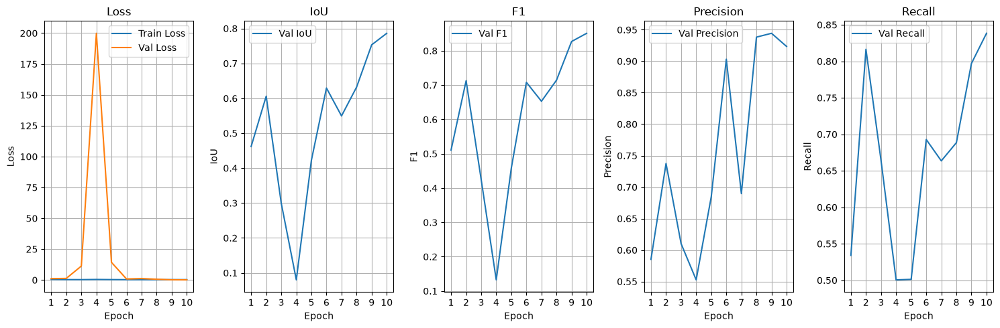

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.507200,1.170948,0.461804,0.510508,0.585175,0.534055
1,2,0.372675,1.339532,0.606012,0.712804,0.737606,0.816489
2,3,0.339772,11.304006,0.299354,0.424828,0.610102,0.664195
3,4,0.470498,199.863464,0.079877,0.132397,0.552639,0.500541
4,5,0.369378,14.317794,0.422428,0.458277,0.684664,0.501218
5,6,0.309793,0.883240,0.629471,0.708249,0.903202,0.692853
6,7,0.304719,1.240178,0.549486,0.653010,0.689688,0.663592
7,8,0.302756,0.652831,0.632134,0.714543,0.938286,0.688502
8,9,0.345404,0.209350,0.753143,0.827227,0.944365,0.797085
9,10,0.335809,0.154886,0.786235,0.851122,0.923490,0.838387


In [12]:
# Performance statistics
geoai.plot_performance_metrics(
    history_path=f"{tiles_dir}/unet_models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

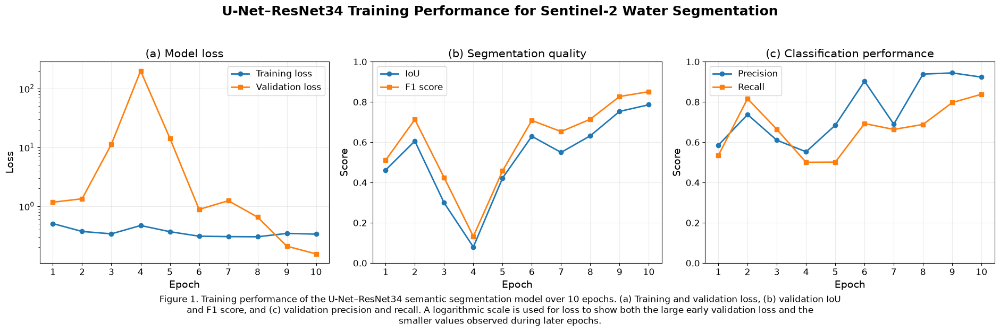

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Load the training history produced by GeoAI
history_path = f"{tiles_dir}/unet_models/training_history.pth"
history = torch.load(history_path, weights_only=False)

# Support the common GeoAI history key names
train_loss = history.get("train_losses", history.get("train_loss"))
val_loss = history.get("val_losses", history.get("val_loss"))

val_iou = history.get("val_ious", history.get("val_iou"))

val_f1 = history.get(
    "val_f1s",
    history.get("val_f1", history.get("val_dices", history.get("val_dice")))
)

val_precision = history.get(
    "val_precisions",
    history.get("val_precision")
)

val_recall = history.get(
    "val_recalls",
    history.get("val_recall")
)

epochs = np.arange(1, len(train_loss) + 1)

# Readable publication-style fonts
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 6)
)

# -------------------------------------------------------
# (a) Training and validation loss
# -------------------------------------------------------
axes[0].plot(
    epochs, train_loss,
    marker="o",
    linewidth=2,
    label="Training loss"
)

axes[0].plot(
    epochs, val_loss,
    marker="s",
    linewidth=2,
    label="Validation loss"
)

axes[0].set_title("(a) Model loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(alpha=0.25)

# -------------------------------------------------------
# (b) IoU and F1
# -------------------------------------------------------
axes[1].plot(
    epochs, val_iou,
    marker="o",
    linewidth=2,
    label="IoU"
)

axes[1].plot(
    epochs, val_f1,
    marker="s",
    linewidth=2,
    label="F1 score"
)

axes[1].set_title("(b) Segmentation quality")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.25)

# -------------------------------------------------------
# (c) Precision and recall
# -------------------------------------------------------
axes[2].plot(
    epochs, val_precision,
    marker="o",
    linewidth=2,
    label="Precision"
)

axes[2].plot(
    epochs, val_recall,
    marker="s",
    linewidth=2,
    label="Recall"
)

axes[2].set_title("(c) Classification performance")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.25)

# Integer epoch labels
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.suptitle(
    "U-Net–ResNet34 Training Performance for Sentinel-2 Water Segmentation",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

import textwrap

caption = (
    "Figure 1. Training performance of the U-Net–ResNet34 semantic segmentation "
    "model over 10 epochs. (a) Training and validation loss, (b) validation IoU "
    "and F1 score, and (c) validation precision and recall. A logarithmic scale "
    "is used for loss to show both the large early validation loss and the smaller "
    "values observed during later epochs."
)

# Wrap caption into multiple lines
wrapped_caption = "\n".join(
    textwrap.wrap(caption, width=150)
)

# Leave space underneath the plots
plt.subplots_adjust(bottom=0.22)

# Add caption below the entire figure
fig.text(
    0.5,            # centred horizontally
    0.02,           # position near bottom
    wrapped_caption,
    ha="center",
    va="bottom",
    fontsize=12
)

plt.savefig(
    "Figure_1_training_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Q4**: Increase the number of training epochs to 10 (this will take some time, so maybe come back to this question later if need be). Present the resulting graphs of performance metrics in a figure and interpret the results for a technical audience (describe the training that has occured and make reccomendations for future training/use of the model). As always, figures should be of publication quality.

**Answer:** Training over 10 epochs produced a clear improvement in segmentation performance. The training loss decreased overall and became relatively stable during the later epochs, indicating that optimisation of the U-Net–ResNet34 weights was progressing. Validation performance improved substantially during the first few epochs: IoU and F1 increased from relatively low initial values to consistently high values later in training, while precision and recall also improved. However, the validation curves did not converge monotonically. Validation loss showed substantial early variation and the IoU, F1 and recall metrics fluctuated between epochs, indicating that model performance on unseen validation samples was still somewhat variable.

The later epochs nevertheless maintained strong validation performance, suggesting that the model had learned useful spatial and multispectral features for separating water from non-water pixels. Precision remained particularly high, indicating relatively few false-positive water predictions, while the slightly lower recall suggests that some true water pixels may still have been missed. Rather than selecting the final epoch automatically, the checkpoint with the best validation IoU or F1 score should be retained for inference. For future training, a lower learning rate or a learning-rate scheduler could be tested once validation performance begins to plateau, together with early stopping to prevent unnecessary training. Additional validation using unseen imagery and qualitative inspection of predicted masks would also be advisable before applying the model to new Sentinel-2 scenes.
AI acknowledgement: This work used ChatGPT 5.6 SoL to generate an initial draft. This was done on 08/10/2026.


In addition to these performance statistics, we can run [inference](https://www.cloudflare.com/learning/ai/inference-vs-training/) on the validation set to evaluate the model's performance. We will use the semantic_segmentation_batch function to process all the validation images at once.

In [14]:
images_dir = f"{data_dir}/dset-s2/val_scene"
masks_dir = f"{data_dir}/dset-s2/val_truth"
predictions_dir = f"{data_dir}/dset-s2/predictions"
model_path = f"{tiles_dir}/unet_models/best_model.pth"

In [15]:
geoai.semantic_segmentation_batch(
    input_dir=images_dir,
    output_dir=predictions_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=6,
    num_classes=2,
    window_size=512,
    overlap=128,
    batch_size=4,
    quiet=True,
)

And then visualize the results of this!

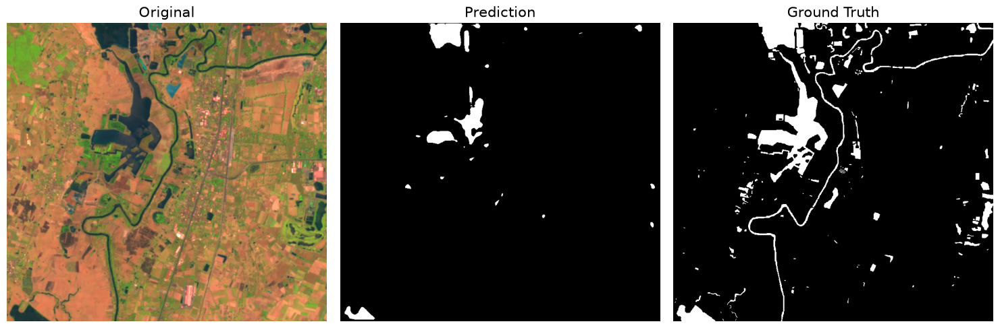

In [16]:
# Visualize inference outcomes
image_id = "S2A_L2A_20190318_N0211_R061"  # Change to other image id, e.g., S2B_L2A_20190620_N0212_R047
test_image_path = f"{data_dir}/dset-s2/val_scene/{image_id}_6Bands_S2.tif"
ground_truth_path = f"{data_dir}/dset-s2/val_truth/{image_id}_S2_Truth.tif"
prediction_path = f"{data_dir}/dset-s2/predictions/{image_id}_6Bands_S2_mask.tif"
save_path = f"{data_dir}/dset-s2/{image_id}_6Bands_S2_comparison.png"

fig = geoai.plot_prediction_comparison(
    original_image=test_image_path,
    prediction_image=prediction_path,
    ground_truth_image=ground_truth_path,
    titles=["Original", "Prediction", "Ground Truth"],
    figsize=(15, 5),
    save_path=save_path,
    show_plot=True,
    indexes=[5, 4, 3],
    divider=5000,
)

**Q5**: Discuss the performance of the prediction in our example given above. Do so in reference to the ability of the prediction to resolve key features as compared to the ground truth (e.g. the river vs. the flood ponds). Explain why perfomance is varying in terms of both satellite data physical principles and the limitations of model and its training.

**Answer**: The prediction performs better for larger flood ponds than for the narrow and meandering river network. Several large water bodies are correctly identified, whereas substantial sections of the river and smaller channels visible in the ground-truth mask are missed. This indicates that the model is relatively conservative in its water predictions and produces a noticeable number of false negatives for narrow water features.
Part of this variation is caused by the physical properties of Sentinel-2 imagery. Large flood ponds contain many neighbouring pixels dominated by water and therefore provide a relatively consistent multispectral signature. In contrast, narrow rivers and water–land boundaries are more affected by mixed pixels, where a single pixel contains reflectance from both water and surrounding land. This makes the spectral signature less distinct. Water reflectance can also vary because of turbidity, shallow depth, aquatic vegetation and shadows, further increasing confusion between water and non-water classes. Mixed pixels and narrow water bodies are recognised limitations when mapping surface water from Sentinel-2 imagery. MDPI

Model limitations also contribute to the observed errors. The ResNet34 encoder progressively downsamples the input while extracting features, so very thin linear structures can become less prominent than large contiguous water bodies. Although U-Net skip connections restore some fine spatial information during decoding, they cannot fully recover features that were poorly represented in the learned feature maps. Performance also depends on the diversity of the training data; if narrow rivers, turbid water or complex shorelines are under-represented, the model is less likely to generalise to these conditions. Finally, converting predicted probabilities into a binary water/non-water mask may remove uncertain boundary pixels. Future improvement could therefore focus on more representative training samples, stronger augmentation of difficult water conditions, and testing the decision threshold to improve recall without creating excessive false positives.

AI acknowledgement: This work used ChatGPT 5.6 SoL to generate an initial draft for the prediction performance and the model limitation part. This was done on 08/10/2026.


Hopefully you can now see the difference that GeoAI makes to your workflow as compared to what we have gone through in the other labs.

Their library is doing a lot of the plumbing and model management for you behind the scenes, allowing you to write faster and solve different problems rather than getting stuck in the weeds. We have only imported one library to accomplish something that before we were using 5 or 6 to do. This does come with drawbacks, choices have been made for you- but particuarly for quick prototyping this is a strong advantage.

Note that the GeoAI tutorial also shows you [how to gather satellite data](https://opengeoai.org/workshops/TNView_2025/#download-sentinel-2-imagery) from a [STAC catalgoue](https://stacspec.org/en). This is the alternative (to the GEE approach used to date) way to build satellite data stacks for use in your project. Might well be useful for you in your projects...

# Task 2: Detecting solar panels from aerial imagery
In Task 1 we used semantic segmentation to classify pixels in satellite imagery. In this task we use a similar deep-learning workflow to identify solar panels in high-resolution aerial imagery, but then move from pixels to individual mapped objects.

The important distinction is that the U-Net produces a pixel-level segmentation. We will then convert that segmentation into polygons and use the geometry of those polygons to remove some of the small or implausible detections. This gives us a simple object-level workflow without introducing a separate object-detection model.

Before starting this task, clear the cache and make sure your RAM is empty from Task 1, or you may crash the Colab instance.

We will work with a labelled training image and vector dataset from Davis, California, and a separate aerial image for testing. The data are provided through [Hugging Face](https://huggingface.co/).

First, we will clear the data and model from Task 1 from our memory. You always want to make sure that a fresh model run has a clean memory to use, as otherwise these free instances will very quickly beocome jammed up and crash:

In [17]:
# Clear memory before starting Task 2
import gc

# Python garbage collection
gc.collect()

# Clear PyTorch GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Report current GPU memory
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3

    print("Memory cleared.")
    print(f"GPU memory allocated: {allocated:.2f} GB")
    print(f"GPU memory reserved:  {reserved:.2f} GB")
else:
    print("Memory cleared. No CUDA GPU detected.")

Memory cleared.
GPU memory allocated: 0.00 GB
GPU memory reserved:  0.00 GB


Next, we specify our data sources and then download them:

In [18]:
# Set the URLS that you are getting the data from
train_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.tif"
train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.geojson"
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_test_davis_ca.tif"

In [19]:
# Use GeoAI to download them
train_raster_path = geoai.download_file(train_raster_url)
train_vector_path = geoai.download_file(train_vector_url)
test_raster_path = geoai.download_file(test_raster_url)

In [20]:
print(train_raster_path)

solar_panels_davis_ca.tif


Let's take a look at it using our own interactive view tool.

In [ ]:
show_interactive(raster=train_raster_path, vector=train_vector_path, title="Training scene")

Q6: Examine the training image and labelled polygons. What visual characteristics distinguish the solar panels from the surrounding roofs, roads and vegetation? Identify at least two characteristics that a convolutional neural network could potentially learn from the imagery.

**Answer:** The labelled solar panels can be distinguished from the surrounding urban surfaces using several visual characteristics. First, solar panels generally form dark blue to dark grey/black regions with relatively consistent colour and brightness, creating contrast with many lighter roofs, concrete roads and green vegetation. However, their apparent brightness can vary with illumination and viewing geometry because photovoltaic surfaces can produce different levels of reflection. Roof colour is therefore an important source of potential confusion. 
Second, the panels have a strong geometric structure. They commonly appear as rectangular or elongated groups with straight edges, sharp corners and repeated parallel arrangements. The labelled polygons in this dataset also largely follow these compact rectangular or elongated panel-array shapes. This differs from vegetation, which tends to have irregular boundaries and heterogeneous texture, and from roads, which are generally much larger continuous linear surfaces. A CNN can learn edge- and shape-related filters in its earlier convolutional layers and combine them in deeper layers into more complex patterns characteristic of panel arrays.

A further useful characteristic is texture and spatial repetition. Individual modules arranged beside one another create a regular, repeating pattern, whereas vegetation tends to have more irregular texture and roofs without panels are often comparatively uniform. Thus, the network does not need to rely on colour alone; it can learn combinations of colour/tone, straight boundaries, rectangular shape, repeated texture and surrounding roof context. This combination is important because dark roofs or shadows may have colours similar to solar panels and could otherwise generate false-positive detections. Studies using U-Net for rooftop photovoltaic segmentation likewise show that roof colour, panel colour, spatial resolution and local urban characteristics affect CNN detection performance.

AI acknowledgement: This work used ChatGPT 5.6 SoL to gather knowledge on geometric structure and texture and spatial repetition part. This was done on 08/10/2026.


We now convert the labelled image into image/label tiles for training.

A 512 × 512 tile is large enough to contain complete solar-panel objects while still being manageable on a Colab GPU. The stride controls how much neighbouring tiles overlap.

In [22]:
out_folder = "solar"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)

'class' not found in vector data. Using default class ID 1.


Generating tiles:   0%|          | 0/312 [00:00<?, ?it/s]

Train a U-Net segmentation model. As in Task 1, the model predicts a class for each pixel. Here the two classes are background and solar panel. This took me 3-5 minutes to train on the GPU. On the CPU it took over 30 minutes:

In [23]:
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,
    batch_size=8,
    num_epochs=10,
    learning_rate=1e-3,
    val_split=0.2,
)

Evaluate the model:

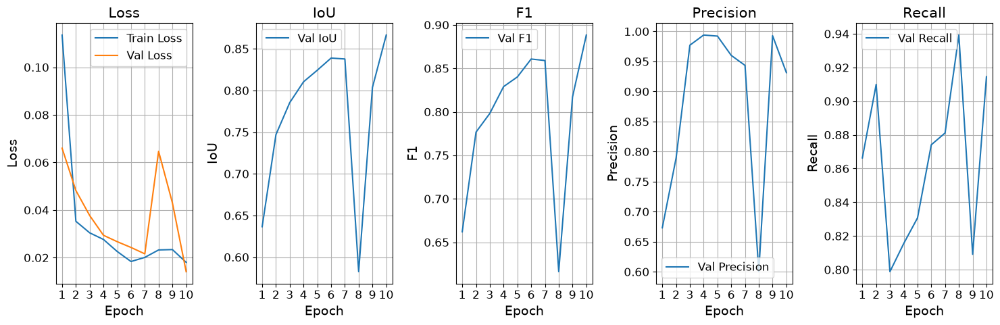

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.113541,0.065997,0.636553,0.662020,0.673190,0.866318
1,2,0.035292,0.048221,0.747042,0.776673,0.789207,0.909922
2,3,0.030453,0.037729,0.785386,0.798172,0.977057,0.798797
3,4,0.027658,0.029416,0.810363,0.829016,0.993986,0.815514
4,5,0.022591,0.026724,0.824301,0.840152,0.992212,0.830711
5,6,0.018394,0.024297,0.838868,0.860744,0.960101,0.874128
6,7,0.020131,0.021620,0.837750,0.859023,0.943477,0.881118
7,8,0.023256,0.064706,0.582589,0.616149,0.600169,0.939258
8,9,0.023413,0.043069,0.803644,0.817102,0.992854,0.809110
9,10,0.018062,0.014121,0.866488,0.888339,0.931471,0.914497


In [24]:
geoai.plot_performance_metrics(
    history_path=f"{out_folder}/models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

Q7: Examine the training and validation curves. Is there evidence that the model is still learning, or that it is beginning to overfit? What would you change about the training process if you wanted to improve the model further?

**Answer:** The model is still learning and does not show clear sustained overfitting. Training loss decreases from roughly 0.11 to below 0.02, while validation loss also ends lower than it began. Validation IoU and F1 generally improve across training and reach their highest values around epoch 10. The sharp deterioration at epoch 8 is temporary because the metrics recover in epochs 9–10; therefore, it looks more like training/validation instability rather than persistent overfitting. Precision is generally very high, while recall is more variable, suggesting that the model sometimes misses true solar-panel pixels.

To improve the model, I would train for a few additional epochs but reduce the learning rate as performance begins to plateau, for example using a learning-rate scheduler. I would also retain the checkpoint with the best validation IoU/F1 rather than automatically using the final epoch. Additional data augmentation and more representative training examples could further improve generalisation, particularly for panels with different sizes, orientations, roof materials and illumination conditions.


Now apply the trained model to the unseen test image. In addition to the usual class mask, we will save the model's probability map. For a two-class problem, the second band contains the probability that each pixel belongs to the solar-panel class.

This is useful because the default mask hides how confident the model was. A pixel just above the classification boundary is different from a pixel for which the model is highly confident.

In [25]:
masks_path = "solar_panels_prediction.tif"
probability_path = "solar_panels_probability.tif"
model_path = f"{out_folder}/models/best_model.pth"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=masks_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_path=probability_path,
)

  0%|          | 0/209 [00:00<?, ?it/s]

Let's look at both the predicted mask.

In [ ]:
show_interactive(raster=test_raster_path, mask=masks_path, probability=probability_path, title="Predictions")

Q8: Compare the binary mask with the probability map. Where does the model appear confident? Where does it appear uncertain? Why might a probability map be more useful than a binary mask when deciding how to improve a detection workflow?

**Answer:** The probability map shows that the model is most confident over the centres of clearly visible solar-panel arrays, where the colours are brightest. These areas also appear consistently in the binary mask. Confidence becomes lower around panel boundaries, small arrays, partially shaded panels and isolated dark objects, where the probability colours become weaker. There are also some uncertain responses on non-panel surfaces, such as parts of roofs and the basketball-court area, showing that objects with similar colour, shape or texture can confuse the model.

The binary mask hides this uncertainty because every pixel is forced into either solar panel or background. In contrast, the probability map shows how strongly the model supports each prediction. This is useful when improving the workflow because we can identify weak false positives and borderline detections, then adjust the probability threshold accordingly. For example, increasing the threshold would remove more low-confidence detections, whereas lowering it could retain additional genuine panels that the model is less certain about. Therefore, the probability map provides much more information for balancing false positives against missed solar-panel pixels than the binary mask alone.

AI acknowledgement: This work used ChatGPT 5.6 SoL to draft and understand the role of probability map and binary mask to improve detection workflow. This was done on 08/10/2026.


Improving the segmentation with a probability threshold:

The default binary result uses the model's class decision. We can instead specify a probability threshold for the solar-panel class. A lower threshold will normally retain more candidate pixels, while a higher threshold will normally produce fewer, more conservative detections.

Run the model again using a threshold of 0.7. Then compare this result with the original prediction.

  0%|          | 0/209 [00:00<?, ?it/s]


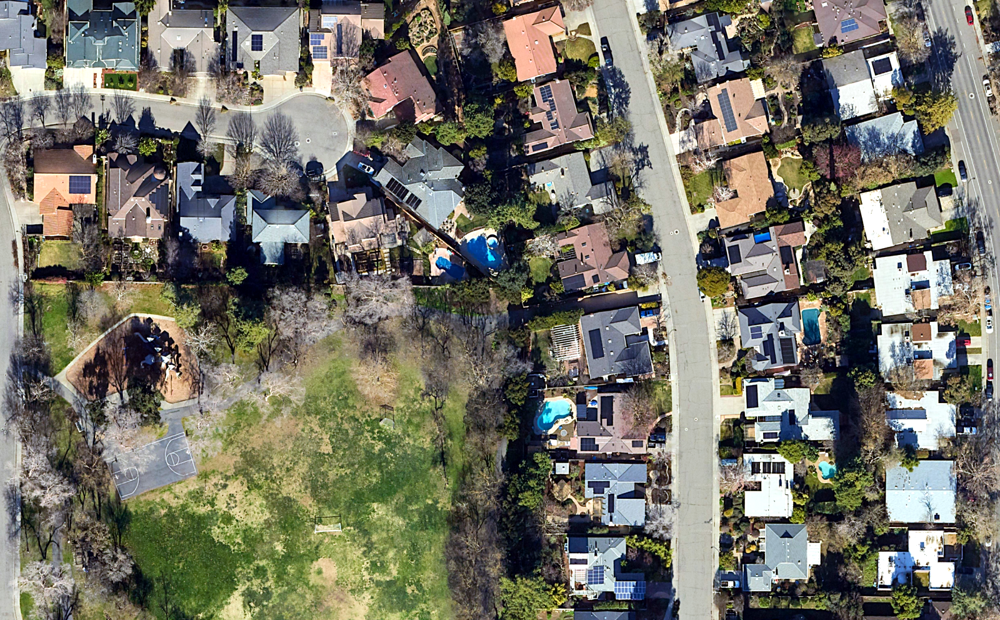
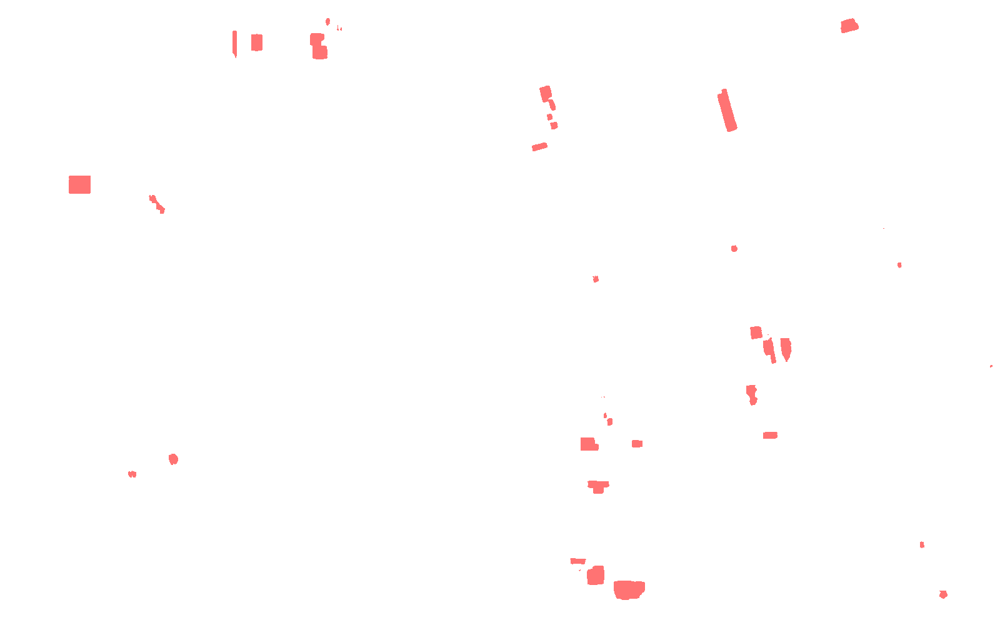
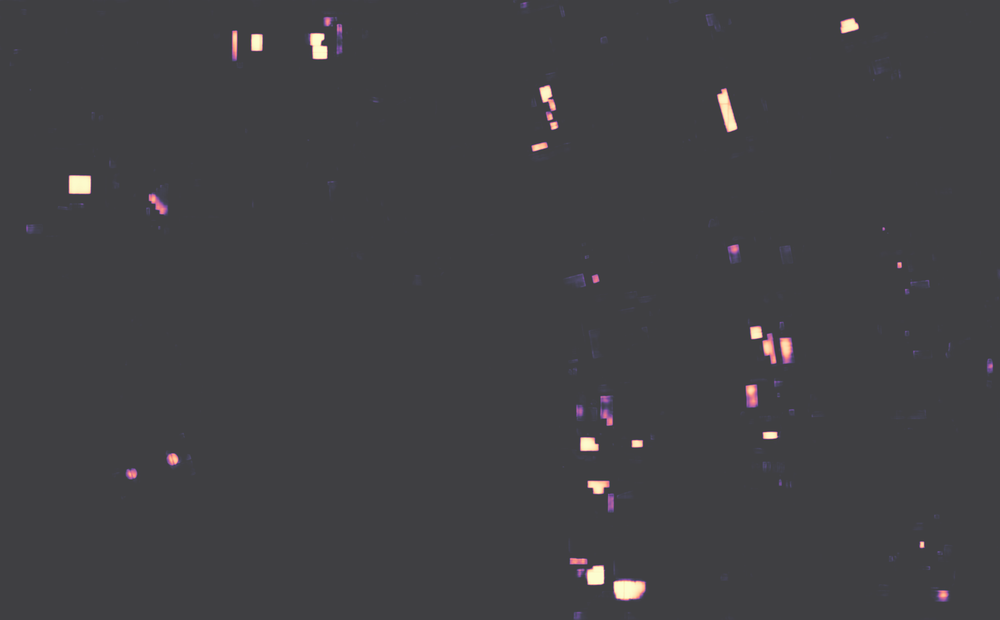

In [37]:
threshold = 0.3
threshold_mask_path = f"solar_panels_prediction_{threshold:.1f}.tif"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=threshold_mask_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_threshold=threshold,
)

show_interactive(raster=test_raster_path, mask=masks_path, probability=probability_path, title="Predictions")

Q9: Experiment with at least two different probability thresholds between 0.3 and 0.9. Compare the resulting masks visually. Which threshold gives you the most useful balance between retaining solar-panel pixels and rejecting false positives? Explain your choice using evidence from the imagery.

Answer: I tested probability thresholds of 0.3, 0.5, 0.7 and 0.85. The visual comparison shows a clear trade-off between retaining candidate solar-panel pixels and removing false positives. At 0.3, the model is very permissive: it retains many small and weak responses, including several isolated detections on roofs and other dark surfaces that do not look like convincing solar panels. At 0.5, many of these weak detections are reduced, while most of the larger rooftop arrays are still retained. Increasing the threshold to 0.7 makes the mask more selective again, removing many scattered low-confidence pixels while preserving the majority of clearly visible rectangular panel arrays. At 0.85, the result becomes noticeably more conservative; although most obvious high-confidence arrays remain, some smaller or weaker genuine panel regions are lost.

From these results, 0.7 gives the most useful balance. It keeps the main solar-panel groups visible across the residential roofs while removing many of the isolated and less plausible detections seen at 0.3 and 0.5. A threshold of 0.85 is cleaner, but it begins to sacrifice potentially valid smaller detections. Therefore, 0.7 provides a better compromise between recall retaining genuine panel pixels and precision rejecting false positives.


From pixels to objects:

The segmentation is still a raster. For many mapping applications we want individual features that can be counted, measured and filtered. We therefore convert the selected mask to polygons and regularise the polygon shapes.

In [29]:
output_path = "solar_panels_prediction.geojson"
gdf = geoai.orthogonalize(threshold_mask_path, output_path, epsilon=2)

print(f"Number of polygons before filtering: {len(gdf)}")

Converting features:   0%|          | 0/44 [00:00<?, ?shape/s]

Number of polygons before filtering: 41


We can now calculate geometric properties for every predicted object. This gives us information such as area, perimeter and shape characteristics that were not available in the raster mask.

In [38]:
gdf_props = geoai.add_geometric_properties(
    gdf,
    area_unit="m2",
    length_unit="m",
)

print(gdf_props[["area_m2", "length_m", "elongation", "solidity"]].describe())

         area_m2   length_m  elongation   solidity
count  41.000000  41.000000   41.000000  41.000000
mean   12.214312  13.309361    2.103965   0.904725
std    17.066652  11.971433    1.637858   0.064000
min     0.016717   0.597192    1.000036   0.769231
25%     0.412363   3.284561    1.200044   0.857143
50%     2.613489   9.256479    1.555612   0.926686
75%    18.155110  20.603055    2.088311   0.955193
max    64.975010  45.684880    9.000327   1.000000


Inspect the distribution of object sizes and shapes, then apply a simple geometric filter. Solar panels are relatively compact, regular objects, whereas tiny isolated detections are often artefacts of the segmentation.

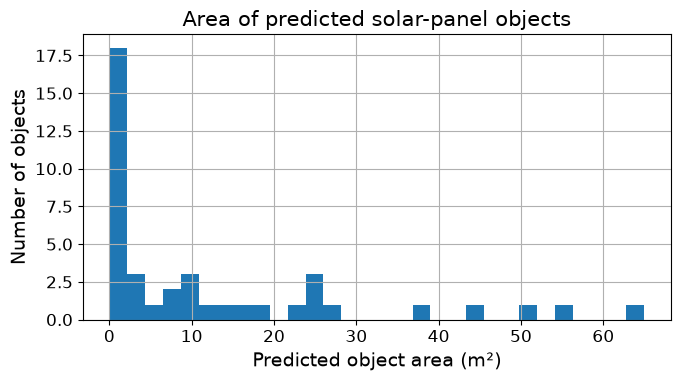

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
gdf_props["area_m2"].hist(bins=30, ax=ax)
ax.set_xlabel("Predicted object area (m²)")
ax.set_ylabel("Number of objects")
ax.set_title("Area of predicted solar-panel objects")
plt.tight_layout()
plt.show()

Q10: Based on the area distribution and the map, choose a minimum object area that removes obvious small artefacts without removing genuine solar panels. State the threshold you chose and explain the trade-off.

Answer: The area histogram is strongly skewed toward very small objects, with most predicted polygons concentrated at the lowest area values and then a clear drop in frequency as object size increases. This suggested that many of the smallest detections were likely segmentation artefacts rather than genuine solar-panel objects. Based on that pattern, I tested 3 m² and 5 m² as reasonable candidate thresholds because they sit near the transition between the dense cluster of tiny detections and the more scattered larger objects.

At 3 m², the number of objects decreased from 41 to 20, removing 21 small detections while keeping the main solar-panel objects visible on the map. Increasing the threshold to 5 m² left 19 objects, so only one additional polygon was removed. I therefore selected 3 m² as the final minimum area because it already removes most of the obvious small artefacts without becoming unnecessarily aggressive.

The trade-off is between removing false positives and preserving genuine small solar-panel installations. A higher threshold gives a cleaner map but increases the risk of deleting real small panels. Thresholds much larger than this, for example somewhere in the 5–30 m² range, would be less appropriate because the histogram shows many plausible detections within that interval. Using such a high cut-off would remove not only artefacts but also a substantial number of realistic small and medium-sized solar-panel objects.

AI acknowledgement: This work used ChatGPT 5.6 SoL to draft the trade-off part. This was done on 08/10/2026.


Note: I have left the vector display as the default settings and they are a little hard to see... you may want to go and expand the code cell at the top of the lab that does the 'show_interactive' and see if you can make it better...

In [41]:
# Change this value after inspecting the area distribution and map.
min_area = 5

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")
print(f"Objects removed:          {len(gdf_props) - len(gdf_filtered)}")

Objects before filtering: 41
Objects after filtering:  19
Objects removed:          22



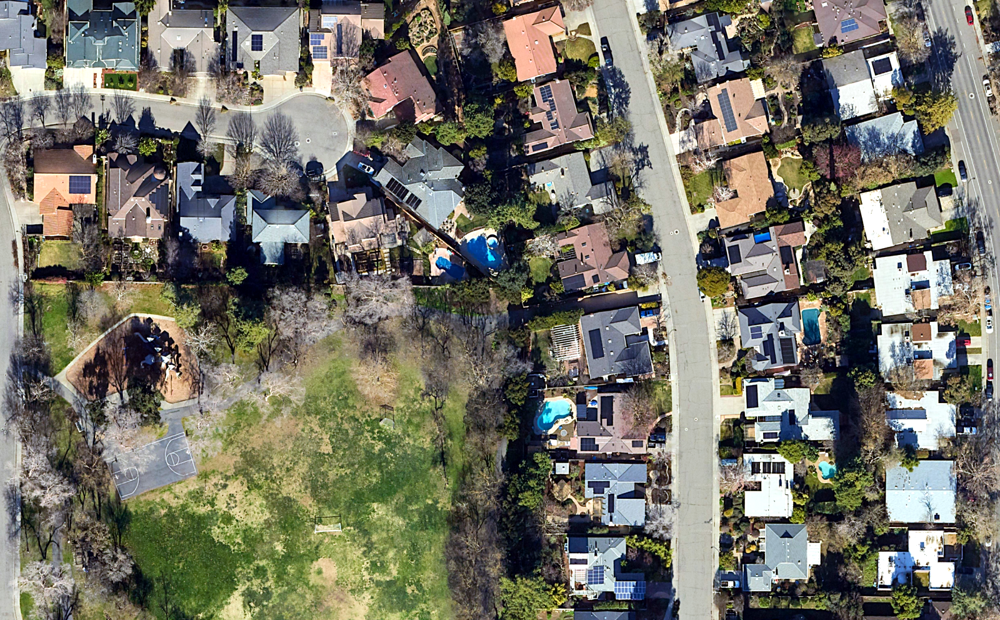

In [42]:
show_interactive(raster=test_raster_path, vector=gdf_filtered, vector_column="area_m2", title="Filtered detections")

Q11: Inspect the filtered predictions against the imagery. Identify two examples where the model has worked well and two examples where it has failed or produced an ambiguous result. For each case, suggest a likely reason for the error.

In [43]:
inspect = gdf_filtered[
    ["area_m2", "length_m", "elongation", "solidity", "geometry"]
].copy()

inspect["object_id"] = inspect.index

inspect[
    ["object_id", "area_m2", "length_m", "elongation", "solidity"]
].sort_values("area_m2")

,object_id,area_m2,length_m,elongation,solidity
26,26,6.698110,19.557955,1.324456,0.799734
21,21,7.812604,14.332600,1.261033,0.930017
24,24,9.116562,12.839674,1.500054,0.980228
4,4,9.606940,18.363430,4.809349,0.949339
12,12,9.801976,17.169356,2.450778,0.930196
23,23,11.952950,16.124289,2.088311,0.960806
18,18,13.323778,17.766380,1.557487,0.943009
17,17,16.121158,18.065057,1.064348,0.961929
19,19,18.155110,22.693199,2.107443,0.934730
3,3,23.766588,20.603055,1.472674,0.983059


In [44]:
inspect[
    ["object_id", "area_m2", "elongation", "solidity"]
].sort_values(
    ["solidity", "elongation"],
    ascending=[False, True]
).head(10)

,object_id,area_m2,elongation,solidity
13,13,51.896421,1.188932,0.987069
3,3,23.766588,1.472674,0.983059
24,24,9.116562,1.500054,0.980228
36,36,38.227150,1.108713,0.965585
40,40,64.975010,1.634468,0.963318
17,17,16.121158,1.064348,0.961929
23,23,11.952950,2.088311,0.960806
25,25,27.567013,1.318230,0.956404
4,4,9.606940,4.809349,0.949339
2,2,23.878037,1.476144,0.947590


In [45]:
print("Highest elongation:")
display(
    inspect[
        ["object_id", "area_m2", "elongation", "solidity"]
    ].sort_values("elongation", ascending=False).head(10)
)

print("Lowest solidity:")
display(
    inspect[
        ["object_id", "area_m2", "elongation", "solidity"]
    ].sort_values("solidity").head(10)
)

Highest elongation:


,object_id,area_m2,elongation,solidity
4,4,9.606940,4.809349,0.949339
11,11,54.420750,3.919327,0.929033
12,12,9.801976,2.450778,0.930196
7,7,23.967197,2.318885,0.780439
19,19,18.155110,2.107443,0.934730
23,23,11.952950,2.088311,0.960806
40,40,64.975010,1.634468,0.963318
6,6,45.209456,1.596985,0.870447
18,18,13.323778,1.557487,0.943009
29,29,24.073074,1.555612,0.880734


Lowest solidity:


,object_id,area_m2,elongation,solidity
7,7,23.967197,2.318885,0.780439
26,26,6.698110,1.324456,0.799734
6,6,45.209456,1.596985,0.870447
29,29,24.073074,1.555612,0.880734
11,11,54.420750,3.919327,0.929033
21,21,7.812604,1.261033,0.930017
12,12,9.801976,2.450778,0.930196
19,19,18.155110,2.107443,0.934730
18,18,13.323778,1.557487,0.943009
2,2,23.878037,1.476144,0.947590


In [ ]:
object_id = 7

candidate = gdf_filtered.loc[[object_id]]

show_interactive(
    raster=test_raster_path,
    vector=candidate,
    vector_column="area_m2",
    title=f"Object {object_id}"
)

Q13: Produce a publication-quality figure from your final result and write a short technical paragraph explaining the complete workflow. Your paragraph should describe:

*   how the training data were created
*   how the U-Net was trained and evaluated;
*   how the probability threshold affected the prediction;
*   how raster predictions were converted into objects
*   how geometric filtering changed the final result

Your discussion should distinguish between what the model learned during training and what you achieved through post-processing. Include references to any external materials you used.

As a final reflection: this workflow is semantic segmentation followed by object extraction, rather than a dedicated object-detection model. Explain one advantage and one limitation of this approach for mapping solar panels.



In [56]:
# Final parameters selected from Q9 and Q10
threshold = 0.7
min_area = 3

threshold_mask_path = f"solar_panels_prediction_{threshold:.1f}.tif"

# Recreate polygons from the FINAL thresholded mask
gdf = geoai.orthogonalize(
    threshold_mask_path,
    "solar_panels_prediction_final.geojson",
    epsilon=2
)

gdf_props = geoai.add_geometric_properties(
    gdf,
    area_unit="m2",
    length_unit="m"
)

gdf_filtered = gdf_props[
    gdf_props["area_m2"] >= min_area
].copy()

print(f"Final probability threshold: {threshold}")
print(f"Minimum object area: {min_area} m²")
print(f"Objects before area filtering: {len(gdf_props)}")
print(f"Objects after area filtering:  {len(gdf_filtered)}")

Converting features:   0%|          | 0/44 [00:00<?, ?shape/s]

Final probability threshold: 0.7
Minimum object area: 3 m²
Objects before area filtering: 41
Objects after area filtering:  20


Converting features:   0%|          | 0/44 [00:00<?, ?shape/s]

Probability threshold: 0.7
Minimum area filter: 3 m²
Objects before filtering: 41
Objects after filtering:  20


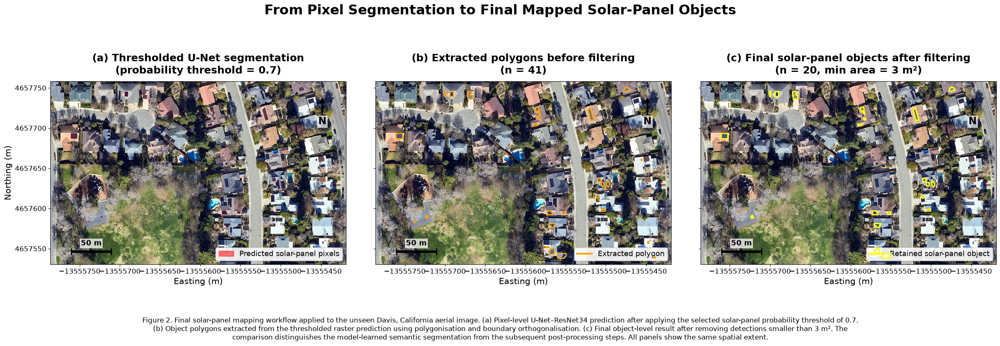

Publication-quality figure saved as: Figure_2_final_solar_panel_workflow_3panel.png


In [55]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import textwrap
import math

# ============================================================
# Final selected parameters
# ============================================================
threshold = 0.7
min_area = 3

threshold_mask_path = f"solar_panels_prediction_{threshold:.1f}.tif"

# Rebuild final polygon layers from the chosen threshold
output_path = "solar_panels_prediction_final.geojson"

gdf = geoai.orthogonalize(
    threshold_mask_path,
    output_path,
    epsilon=2
)

gdf_props = geoai.add_geometric_properties(
    gdf,
    area_unit="m2",
    length_unit="m"
)

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Probability threshold: {threshold}")
print(f"Minimum area filter: {min_area} m²")
print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")


# ============================================================
# Helper functions
# ============================================================
def percentile_stretch(rgb, low=2, high=98):
    """Stretch RGB image for clearer display."""
    rgb = rgb.astype(np.float32)
    out = np.zeros_like(rgb, dtype=np.float32)

    for i in range(rgb.shape[2]):
        band = rgb[:, :, i]
        valid = np.isfinite(band)
        p_low, p_high = np.percentile(band[valid], [low, high])

        if p_high > p_low:
            out[:, :, i] = np.clip((band - p_low) / (p_high - p_low), 0, 1)

    return out


def nice_scale_length(map_width):
    """Choose a visually sensible scale-bar length."""
    target = map_width * 0.18
    magnitude = 10 ** math.floor(math.log10(target))
    normalized = target / magnitude

    if normalized < 1.5:
        nice = 1
    elif normalized < 3.5:
        nice = 2
    elif normalized < 7.5:
        nice = 5
    else:
        nice = 10

    return nice * magnitude


def add_scale_bar(ax, bounds):
    """Add a scale bar assuming CRS units are metres."""
    width = bounds.right - bounds.left
    height = bounds.top - bounds.bottom

    scale_length = nice_scale_length(width)

    x0 = bounds.left + 0.07 * width
    y0 = bounds.bottom + 0.07 * height

    ax.plot(
        [x0, x0 + scale_length],
        [y0, y0],
        color="black",
        linewidth=4.5,
        solid_capstyle="butt",
        zorder=50
    )

    tick_height = 0.015 * height

    ax.plot(
        [x0, x0],
        [y0 - tick_height, y0 + tick_height],
        color="black",
        linewidth=2,
        zorder=50
    )
    ax.plot(
        [x0 + scale_length, x0 + scale_length],
        [y0 - tick_height, y0 + tick_height],
        color="black",
        linewidth=2,
        zorder=50
    )

    label = f"{int(scale_length/1000)} km" if scale_length >= 1000 else f"{int(scale_length)} m"

    ax.text(
        x0 + scale_length / 2,
        y0 + 0.025 * height,
        label,
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
        zorder=51
    )


def add_north_arrow(ax):
    """Add a north arrow."""
    ax.annotate(
        "N",
        xy=(0.92, 0.92),
        xytext=(0.92, 0.78),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold",
        color="black",
        arrowprops=dict(
            arrowstyle="-|>",
            facecolor="black",
            edgecolor="black",
            linewidth=2.2
        ),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=2),
        zorder=60
    )


# ============================================================
# Read aerial image
# ============================================================
with rasterio.open(test_raster_path) as src:
    rgb = src.read([1, 2, 3])
    rgb = np.moveaxis(rgb, 0, -1)
    rgb = percentile_stretch(rgb)
    bounds = src.bounds
    raster_crs = src.crs

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Read final thresholded raster mask
with rasterio.open(threshold_mask_path) as src:
    final_mask = src.read(1)

# Ensure polygon CRS matches raster
gdf_before = gdf_props.copy()
gdf_after = gdf_filtered.copy()

if gdf_before.crs != raster_crs:
    gdf_before = gdf_before.to_crs(raster_crs)

if gdf_after.crs != raster_crs:
    gdf_after = gdf_after.to_crs(raster_crs)


# ============================================================
# Figure style
# ============================================================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13
})

fig, axes = plt.subplots(
    1, 3,
    figsize=(25, 8.8),
    sharex=True,
    sharey=True
)

# ============================================================
# Panel (a): segmentation result
# ============================================================
axes[0].imshow(rgb, extent=extent, origin="upper")

masked_prediction = np.ma.masked_where(final_mask == 0, final_mask)

axes[0].imshow(
    masked_prediction,
    extent=extent,
    origin="upper",
    cmap="Reds",
    alpha=0.55,
    vmin=0,
    vmax=1
)

axes[0].set_title(
    f"(a) Thresholded U-Net segmentation\n(probability threshold = {threshold})",
    fontweight="bold",
    pad=14
)

# ============================================================
# Panel (b): polygons before filtering
# ============================================================
axes[1].imshow(rgb, extent=extent, origin="upper")

gdf_before.plot(
    ax=axes[1],
    facecolor="none",
    edgecolor="orange",
    linewidth=2.0,
    zorder=20
)

axes[1].set_title(
    f"(b) Extracted polygons before filtering\n(n = {len(gdf_before)})",
    fontweight="bold",
    pad=14
)

# ============================================================
# Panel (c): final polygons after filtering
# ============================================================
axes[2].imshow(rgb, extent=extent, origin="upper")

gdf_after.plot(
    ax=axes[2],
    facecolor="none",
    edgecolor="yellow",
    linewidth=2.2,
    zorder=20
)

axes[2].set_title(
    f"(c) Final solar-panel objects after filtering\n(n = {len(gdf_after)}, min area = {min_area} m²)",
    fontweight="bold",
    pad=14
)

# ============================================================
# Common layout and map elements
# ============================================================
for ax in axes:
    ax.set_xlim(bounds.left, bounds.right)
    ax.set_ylim(bounds.bottom, bounds.top)
    ax.set_xlabel("Easting (m)")

    if raster_crs is not None and raster_crs.is_projected:
        add_scale_bar(ax, bounds)

    add_north_arrow(ax)

    ax.ticklabel_format(style="plain", axis="both", useOffset=False)

axes[0].set_ylabel("Northing (m)")

# ============================================================
# Legends
# ============================================================
seg_patch = mpatches.Patch(
    facecolor="red",
    edgecolor="red",
    alpha=0.55,
    label="Predicted solar-panel pixels"
)

before_line = Line2D(
    [0], [0],
    color="orange",
    linewidth=3,
    label="Extracted polygon"
)

after_line = Line2D(
    [0], [0],
    color="yellow",
    linewidth=3,
    label="Retained solar-panel object"
)

axes[0].legend(
    handles=[seg_patch],
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.90
)

axes[1].legend(
    handles=[before_line],
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.90
)

axes[2].legend(
    handles=[after_line],
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.90
)

# ============================================================
# Main title
# ============================================================
fig.suptitle(
    "From Pixel Segmentation to Final Mapped Solar-Panel Objects",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

# ============================================================
# Caption
# ============================================================
caption = (
    "Figure 2. Final solar-panel mapping workflow applied to the unseen Davis, California aerial image. "
    "(a) Pixel-level U-Net–ResNet34 prediction after applying the selected solar-panel probability threshold of 0.7. "
    "(b) Object polygons extracted from the thresholded raster prediction using polygonisation and boundary orthogonalisation. "
    f"(c) Final object-level result after removing detections smaller than {min_area} m². "
    "The comparison distinguishes the model-learned semantic segmentation from the subsequent post-processing steps. "
    "All panels show the same spatial extent."
)

wrapped_caption = "\n".join(textwrap.wrap(caption, width=210))

plt.subplots_adjust(
    left=0.06,
    right=0.985,
    top=0.86,
    bottom=0.16,
    wspace=0.10
)

fig.text(
    0.5,
    0.04,
    wrapped_caption,
    ha="center",
    va="bottom",
    fontsize=12.5
)

# ============================================================
# Save figure
# ============================================================
figure_path = "Figure_2_final_solar_panel_workflow_3panel.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Publication-quality figure saved as: {figure_path}")